In [40]:
# # Kluczowy wniosek po EDA do treningu: 
# - Łagodny imbalans klas (44.6% / 55.4%), wagi do class weighting policzone
# - Asymetria jakości obrazów między klasami (nevus ma znacznie wyższą rozdzielczość) — ryzyko shortcut learning
# - Duplikaty wewnątrz klas do usunięcia przed treningiem, brak duplikatów między klasami (brak błędu etykietowania)

In [ ]:
## Kroki EDA — ISIC 2019+2020 Melanoma Dataset (mel vs nevus)

# 1. **Importy** — biblioteki (`os`, `hashlib`, `numpy`, `pandas`, `matplotlib`, `Path`, `PIL.Image`)

# 2. **Ścieżki do danych** — `BASE_DIR`, `MEL_DIR`, `NEVUS_DIR`

# 3. **Liczba obrazów per klasa** — mel: 5106, nevus: 6343

# 4. **Wagi do class weighting** — w_malignant ≈ 1.12, w_benign ≈ 0.90

# 5. **Sprawdzenie plików `_downsampled`** — 7.3% w mel, 0% w nevus

# 6. **Rozmiary obrazów** — nevus ~3x większa rozdzielczość niż mel

# 7. **Duplikaty (hash MD5)**:
#    - **7a** — test na próbce (1000 plików): 2 duplikaty w mel, 2 w nevus
#    - **7b** — sprawdzenie konkretnych nazw plików + duplikatów między klasami (wynik: 0)
#    - **7c** — pełny zbiór: 11 duplikatów w mel, 37 w nevus, 0 między klasami

# 8. **Podgląd obrazów** — wizualne porównanie mel vs nevus

SyntaxError: invalid character '—' (U+2014) (8504776.py, line 3)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import hashlib
import os

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# te dane sa na Kaggle, wiec jak chcesz trenowac lokalnie to pobierz:
# 

BASE_DIR = Path("/kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20")

MEL_DIR = BASE_DIR / "mel"
NEVUS_DIR = BASE_DIR / "nevus"

for p in [BASE_DIR, MEL_DIR, NEVUS_DIR]:
    exists = p.exists()
    print(p, "->", "OK" if exists else "BRAK")

/kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20 -> OK
/kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20/mel -> OK
/kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20/nevus -> OK


In [31]:
mel_files = list(MEL_DIR.glob("*.jpg"))
nevus_files = list(NEVUS_DIR.glob("*.jpg"))

n_mel = len(mel_files)
n_nevus = len(nevus_files)
total = n_mel + n_nevus

print("mel (malignant):", n_mel, "plikow")
print("nevus (benign):", n_nevus, "plikow")
print("Razem:", total)

mel (malignant): 5106 plikow
nevus (benign): 6343 plikow
Razem: 11449


In [33]:
# liczymy wagi aby rownowazyc klasy

w_malignant = total / (2 * n_mel)
w_benign = total / (2 * n_nevus)

print("w_malignant (mel):", round(w_malignant, 4))
print("w_benign (nevus):", round(w_benign, 4))
print("Stosunek wag:", round(max(w_malignant, w_benign) / min(w_malignant, w_benign), 2))

w_malignant (mel): 1.1211
w_benign (nevus): 0.9025
Stosunek wag: 1.24


In [34]:
# Chcemy sprawdzić, czy pliki _downsampled są równo rozłożone 
# między klasami. Jeśli np. 40% plików mel jest downsampled, 
# a tylko 5% nevus — to może być problem, 
# bo model mógłby nauczyć się rozróżniać klasy po jakości/rozdzielczości obrazu, 
# a nie po faktycznej zmianie skórnej. 
# To byłby fałszywy sygnał (tzw. data leakage / shortcut learning).

mel_down = [f for f in mel_files if '_downsampled' in f.stem]
nevus_down = [f for f in nevus_files if '_downsampled' in f.stem]

print("mel downsampled:", len(mel_down), "/", n_mel)
print("nevus downsampled:", len(nevus_down), "/", n_nevus)
print("Procent mel:", round(len(mel_down)/n_mel*100, 1), "%")
print("Procent nevus:", round(len(nevus_down)/n_nevus*100, 1), "%")

mel downsampled: 374 / 5106
nevus downsampled: 0 / 6343
Procent mel: 7.3 %
Procent nevus: 0.0 %


In [ ]:
# Procent mel: 7.3 %
# Procent nevus: 0.0 %
# To jest ważne znalezisko — i realny problem, nie kosmetyka.
# Co to znaczy: 7.3% obrazów mel jest downsampled (czyli ma niższą rozdzielczość niż reszta), a w nevus zero takich plików. To asymetria tylko w jednej klasie.
# Dlaczego to ryzykowne: model podczas treningu mógłby nauczyć się skrótu — "obrazy o gorszej jakości/niższej rozdzielczości = mel" — zamiast uczyć się faktycznych cech zmiany skórnej (kolor, kształt, asymetria). To się nazywa shortcut learning — model "oszukuje", łapiąc się losowego artefaktu w danych zamiast prawdziwego sygnału. Działałoby to dobrze na tym zbiorze, ale kompletnie zawiodłoby na nowych, realnych zdjęciach.
# Co warto sprawdzić dalej (krok 7): czy te 374 pliki faktycznie mają zauważalnie inną rozdzielczość niż reszta — to zaraz zrobimy w sekcji o rozmiarach obrazów (będzie osobny podział na downsampled vs nie).
# Możliwe rozwiązania na później (przy treningu), do rozważenia — nie musisz jeszcze decydować:
# Usunąć te 374 pliki z treningu (najprostsze, tracisz trochę danych mel)
# Sztucznie "downsamplować" losową część nevus w tej samej proporcji, żeby wyrównać
# Zignorować, jeśli różnica rozdzielczości okaże się w praktyce mała po resize do 300×300 (bo i tak wszystko skalujesz do jednego rozmiaru przed wejściem do EfficientNet — więc jeśli różnica zniknie po resize, problem może być nieistotny)

In [35]:
# Rozmiary obrazów

def sample_dims(files, n=200, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(files), size=min(n, len(files)), replace=False)
    sample = [files[i] for i in idx]
    dims = []
    for f in sample:
        with Image.open(f) as img:
            dims.append({'width': img.width, 'height': img.height, 'downsampled': '_downsampled' in f.stem})
    return pd.DataFrame(dims)

mel_dims = sample_dims(mel_files, n=200)
nevus_dims = sample_dims(nevus_files, n=200)

print("MEL - rozmiary wg downsampled:")
print(mel_dims.groupby('downsampled')[['width', 'height']].mean())

print("\nNEVUS - rozmiary:")
print(nevus_dims[['width', 'height']].mean())

MEL - rozmiary wg downsampled:
                   width       height
downsampled                          
False        1199.092391  1024.266304
True         1024.000000   708.125000

NEVUS - rozmiary:
width     3236.375
height    2133.830
dtype: float64


In [ ]:
# To pokazuje coś ważniejszego niż sam problem z _downsampled — cała klasa nevus ma dużo większe obrazy niż mel, nie tylko te oznaczone jako downsampled.

# Porównaj:

# mel (nawet te "normalne", nie-downsampled): ~1199×1024
# nevus: ~3236×2133

# To jest prawie 3× różnica w rozdzielczości między całymi klasami, nie tylko w tych 374 plikach. To poważniejszy sygnał niż myśleliśmy — model bardzo łatwo mógłby nauczyć się rozróżniać klasy po rozmiarze/jakości obrazu, zamiast po faktycznych cechach zmiany skórnej.

In [36]:
# Duplikaty (hash MD5)
# Najpierw krótkie wyjaśnienie idei: hash to funkcja, która zamienia zawartość pliku na krótki ciąg znaków (tzw. "odcisk palca"). Dwa identyczne pliki zawsze dadzą identyczny hash. Dzięki temu możemy porównywać pliki bez otwierania ich wizualnie — jeśli dwa pliki mają ten sam hash, są bit-w-bit identyczne.

# Uwaga na start: liczenie hashy dla wszystkich 11 449 plików może chwilę potrwać (parę minut). Zacznijmy od próbki, żeby sprawdzić czy kod działa, zanim odpalisz na całości.

def file_md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

SAMPLE_N = 1000  # na start mala proba zeby sprawdzic czy kod dziala, pozniej zwiekszymy

def hash_files(files, n):
    sample = files[:n]
    hashes = {}
    for f in sample:
        h = file_md5(f)
        hashes.setdefault(h, []).append(f.name)
    return hashes

mel_hashes = hash_files(mel_files, SAMPLE_N)
nevus_hashes = hash_files(nevus_files, SAMPLE_N)

mel_dups = {h: names for h, names in mel_hashes.items() if len(names) > 1}
nevus_dups = {h: names for h, names in nevus_hashes.items() if len(names) > 1}

print("Duplikaty w probce mel:", len(mel_dups))
print("Duplikaty w probce nevus:", len(nevus_dups))

Duplikaty w probce mel: 2
Duplikaty w probce nevus: 2


In [37]:
# Krok 8b: Zobaczmy konkretne duplikaty + sprawdźmy między klasami

print("Duplikaty w mel:")
for h, names in mel_dups.items():
    print(" ", names)

print("\nDuplikaty w nevus:")
for h, names in nevus_dups.items():
    print(" ", names)

# Sprawdzenie duplikatow MIEDZY klasami - to bylby powazny blad etykietowania
cross = set(mel_hashes.keys()) & set(nevus_hashes.keys())
print("\nDuplikaty MIEDZY mel i nevus:", len(cross))
for h in cross:
    print(" mel:", mel_hashes[h], " vs nevus:", nevus_hashes[h])


Duplikaty w mel:
  ['ISIC_0056130.jpg', 'ISIC_0054334.jpg']
  ['ISIC_0062983.jpg', 'ISIC_0064339.jpg']

Duplikaty w nevus:
  ['ISIC_9104012.jpg', 'ISIC_3927991.jpg']
  ['ISIC_1392702.jpg', 'ISIC_5006118.jpg']

Duplikaty MIEDZY mel i nevus: 0


In [38]:
# Krok 8c: Duplikaty na pełnym zbiorze

mel_hashes_full = hash_files(mel_files, len(mel_files))
nevus_hashes_full = hash_files(nevus_files, len(nevus_files))

mel_dups_full = {h: names for h, names in mel_hashes_full.items() if len(names) > 1}
nevus_dups_full = {h: names for h, names in nevus_hashes_full.items() if len(names) > 1}

print("Duplikaty w calym mel:", len(mel_dups_full))
print("Duplikaty w calym nevus:", len(nevus_dups_full))

cross_full = set(mel_hashes_full.keys()) & set(nevus_hashes_full.keys())
print("Duplikaty MIEDZY mel i nevus:", len(cross_full))

Duplikaty w calym mel: 11
Duplikaty w calym nevus: 37
Duplikaty MIEDZY mel i nevus: 0


In [ ]:
# Dobry wynik. Podsumujmy co mamy:

# 11 duplikatów w mel, 37 w nevus — to niewielki procent całości (11/5106 ≈ 0.2%, 37/6343 ≈ 0.6%), nic dramatycznego
# 0 duplikatów między klasami — potwierdzone na pełnym zbiorze, żadnego błędu etykietowania

# To są liczby par, więc realnie do usunięcia będzie ok. 11-22 plików z mel i 37-74 z nevus (zależnie ile duplikatów ma każda grupa) — przy treningu wystarczy zostawić jeden plik z każdej pary, usunąć resztę.

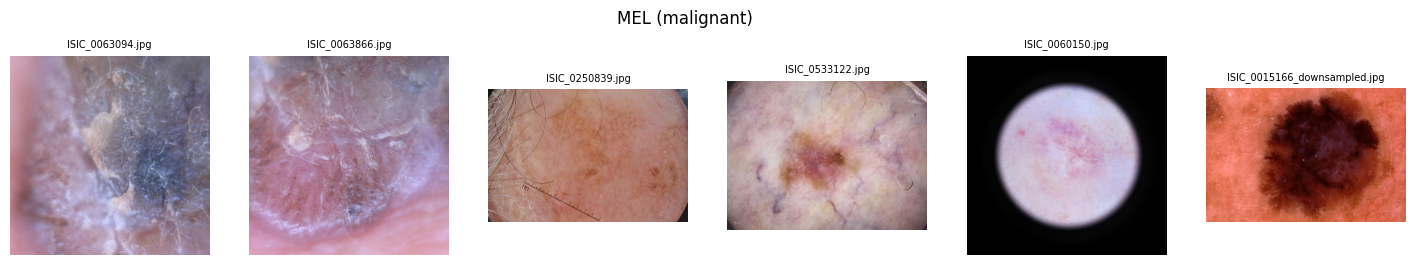

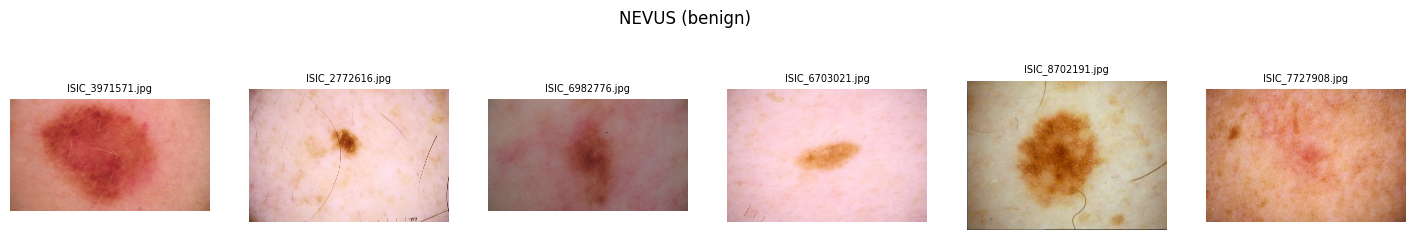

In [39]:
# Krok 9: Podgląd przykładowych obrazów

def show_samples(files, n=6, title=""):
    rng = np.random.default_rng(42)
    idx = rng.choice(len(files), size=n, replace=False)
    sample = [files[i] for i in idx]
    
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, f in zip(axes, sample):
        img = Image.open(f)
        ax.imshow(img)
        ax.set_title(f.name, fontsize=7)
        ax.axis('off')
    fig.suptitle(title)
    plt.show()

show_samples(mel_files, n=6, title="MEL (malignant)")
show_samples(nevus_files, n=6, title="NEVUS (benign)")